# 1. Setup & Environment
- 공간 시각화 라이브러리(GeoPandas, Matplotlib) 로드
- 한글 폰트(NanumGothic) 및 유니코드 마이너스 깨짐 방지 설정

In [1]:
from pathlib import Path
import warnings

import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

# 폰트 및 유니코드 설정
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

# 2. Configuration & Academic Cartographic Palette
- 분석 대상 연도(2021~2024), 2개 비교 모형(2SFCA, Gravity) 및 입출력 경로 정의
- ColorBrewer 기반 학술 논문 표준 RdBu 색상 체계 및 미니멀리스트 테마 설정

In [2]:
# 경로 설정
BASE_DIR = Path("/mnt/cowork/EV")
BOUNDARY_FP = BASE_DIR / "input/raw/집계구_2016/집계구.shp"
DIR_MAPS = BASE_DIR / "output/maps"
DIR_MAPS.mkdir(parents=True, exist_ok=True)

OUT_FP = DIR_MAPS / "two_model_hotspot_k30_academic_mw.png"

# 분석 파라미터 및 라벨 정의
YEARS = [2021, 2022, 2023, 2024]
MODELS = ["2SFCA", "Gravity"]
MODEL_LABEL = {
    "2SFCA": "Gaussian 2SFCA",
    "Gravity": "Gravity Model"
}

# ColorBrewer RdBu 기반 학술 지도 컬러 팔레트
PALETTE = {
    "HOT": "#d73027",       # Hot Spot (Crimson Red)
    "COLD": "#2166ac",      # Cold Spot (Navy Blue)
    "NOT_SIG": "#f0f0f0",   # Not Significant (Light Gray)
    "BORDER": "#bdbdbd",    # 집계구 기본 경계선 색상
    "TEXT": "#222222",      # 라벨 텍스트 색상
    "MUTED": "#666666"      # 부제 텍스트 색상
}

print(f">> 시각화 구성: {len(MODELS)}개 모형 x {len(YEARS)}개년 = 총 {len(MODELS)*len(YEARS)}개 패널 (2행 4열)")

>> 시각화 구성: 2개 모형 x 4개년 = 총 8개 패널 (2행 4열)


# 3. Boundary & Hotspot Data Loader
- 서울시 14,979개 집계구 폴리곤(EPSG:5179) 로드 및 전처리
- 신규 표준 산출물(`two_model_hotspot_k30_mw.csv`) 우선 로드

In [3]:
# 서울시 집계구 폴리곤 로드
gdf = gpd.read_file(BOUNDARY_FP).set_crs(epsg=5179, allow_override=True)
gdf["TOT_REG_CD"] = gdf["TOT_REG_CD"].astype(str)
gdf_seoul = gdf[gdf["TOT_REG_CD"].str.startswith("11")].copy().reset_index(drop=True)
print(f">> 서울시 집계구 경계 로드 완료: 총 {len(gdf_seoul):,}개 폴리곤")

# 핫스팟 비교 데이터 로드 (_mw 우선 탐색)
fp_hotspot_mw = BASE_DIR / "output/two_model_hotspot_k30_mw.csv"
fp_hotspot_orig = BASE_DIR / "output/two_model_hotspot_k30.csv"

if fp_hotspot_mw.exists():
    fp_hotspot = fp_hotspot_mw
    print(f">> 신규 리팩토링 산출물 로드: {fp_hotspot.name}")
elif fp_hotspot_orig.exists():
    fp_hotspot = fp_hotspot_orig
    print(f">> 기존 원본 산출물 로드: {fp_hotspot.name}")
else:
    raise FileNotFoundError("핫스팟 분석 결과 CSV 파일이 존재하지 않습니다.")

df_hotspot = pd.read_csv(fp_hotspot, dtype={"oa_code": str})

>> 서울시 집계구 경계 로드 완료: 총 19,153개 폴리곤
>> 신규 리팩토링 산출물 로드: two_model_hotspot_k30_mw.csv


# 4. Multi-Panel Cartographic Rendering (2 Rows x 4 Columns)
- 2행 4열 서브플롯 그리드 구성 및 모형·연도별 군집 지도 렌더링
- 집계구 경계 노이즈 제거 및 시각적 대비 극대화를 위한 군집별 디졸브(Dissolve) 플롯
- dissolve 직후 부동소수점 오차로 남는 미세 seam(스펙클) 제거용 소버퍼(+1m/-1m) 스냅 적용

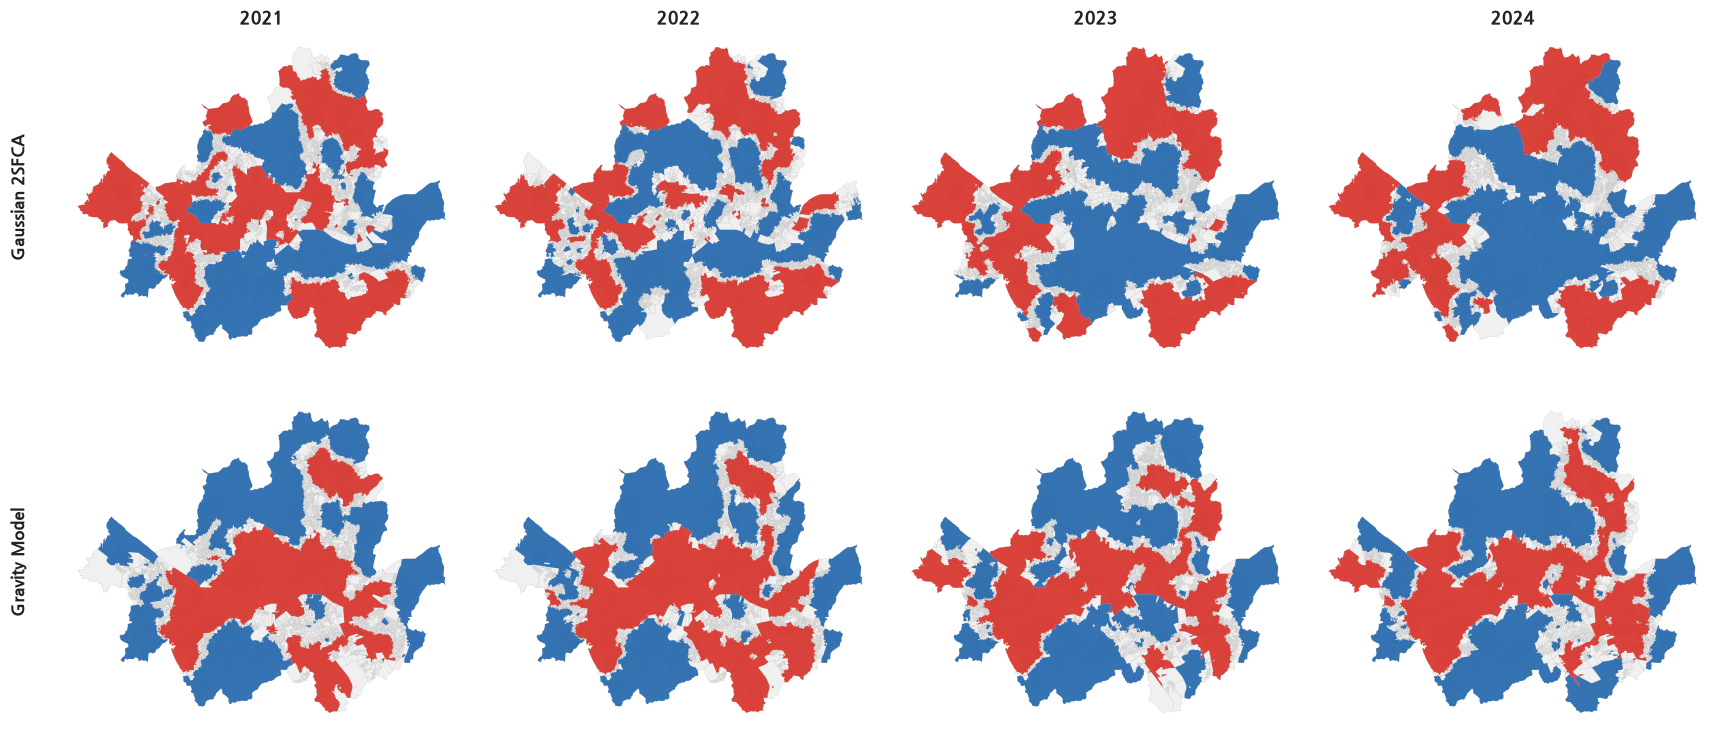

In [4]:
fig, axes = plt.subplots(
    nrows=len(MODELS),
    ncols=len(YEARS),
    figsize=(18, 9),
    facecolor="white"
)
plt.subplots_adjust(top=0.88, bottom=0.10, left=0.06, right=0.98, hspace=0.08, wspace=0.03)

for r, model in enumerate(MODELS):
    for c, year in enumerate(YEARS):
        ax = axes[r, c]

        # 모형-연도 조건 슬라이싱
        sub_df = df_hotspot[(df_hotspot["model"] == model) & (df_hotspot["year"] == year)].set_index("oa_code")
        g = gdf_seoul.copy()
        g["gi_class"] = g["TOT_REG_CD"].map(sub_df["gi_class"]).fillna("Not Sig")

        # 기본 배경 집계구 (Not Significant)
        g.plot(ax=ax, color=PALETTE["NOT_SIG"], edgecolor=PALETTE["BORDER"], linewidth=0.15)

        # 군집 디졸브 렌더링
        dissolved = g.dissolve(by="gi_class")
        # 인접 집계구 경계가 부동소수점 정밀도 차이로 완전히 안 붙어서 dissolve가
        # 매끈한 폴리곤 대신 미세하게 끊긴 조각(스펙클)을 남기는 문제 — 작은 버퍼로 스냅
        dissolved["geometry"] = dissolved.geometry.buffer(1).buffer(-1)
        if "Hot Spot" in dissolved.index:
            dissolved.loc[["Hot Spot"]].plot(ax=ax, color=PALETTE["HOT"], edgecolor="none", alpha=0.9)
        if "Cold Spot" in dissolved.index:
            dissolved.loc[["Cold Spot"]].plot(ax=ax, color=PALETTE["COLD"], edgecolor="none", alpha=0.9)

        ax.set_axis_off()

        # 열 타이틀 (연도)
        if r == 0:
            ax.set_title(f"{year}", fontsize=13, fontweight="bold", color=PALETTE["TEXT"], pad=6)

        # 행 라벨 (모형명)
        if c == 0:
            ax.text(
                -0.08, 0.5, MODEL_LABEL[model],
                transform=ax.transAxes, ha="right", va="center",
                fontsize=12, fontweight="bold", color=PALETTE["TEXT"], rotation=90
            )

# 5. Shared Legend, Academic Header & High-Res Export
- 전체 메인 타이틀 및 분석 파라미터 캡션 설정
- 하단 중앙 통합 수평 범례 배치 및 논문 제출용 고해상도 이미지(`_mw.png`) 저장

In [5]:
# 메인 헤더 및 파라미터 캡션
fig.suptitle(
    "Spatial Clustering of EV Accessibility: Gaussian 2SFCA vs Gravity Model",
    fontsize=16, fontweight="bold", color=PALETTE["TEXT"], y=0.96
)
fig.text(
    0.52, 0.92,
    "Weekdays Daytime (11:00-13:00) | Local Getis-Ord Gi* (KNN k=30, p < 0.05)",
    ha="center", fontsize=11, color=PALETTE["MUTED"]
)

# 공통 수평 범례 (하단 중앙)
legend_handles = [
    mpatches.Patch(color=PALETTE["HOT"], label="Hot Spot (p < 0.05)"),
    mpatches.Patch(color=PALETTE["COLD"], label="Cold Spot (p < 0.05)"),
    mpatches.Patch(facecolor=PALETTE["NOT_SIG"], edgecolor=PALETTE["BORDER"], linewidth=0.5, label="Not Significant"),
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    frameon=False,
    fontsize=11,
    bbox_to_anchor=(0.52, 0.02)
)

# 고해상도(300 DPI) 이미지 내보내기 및 화면 출력
plt.savefig(OUT_FP, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f">> 학술 논문 스타일 고해상도 지도 저장 완료: {OUT_FP}")

<Figure size 640x480 with 0 Axes>

>> 학술 논문 스타일 고해상도 지도 저장 완료: /mnt/cowork/EV/output/maps/two_model_hotspot_k30_academic_mw.png


# 6. Export File Verification
- 저장된 300 DPI 래스터 이미지 파일의 경로 및 용량(MB) 무결성 확인

In [6]:
if OUT_FP.exists():
    file_size_mb = OUT_FP.stat().st_size / (1024 * 1024)
    print("=" * 70)
    print(f"  파일명    : {OUT_FP.name}")
    print(f"  절대 경로 : {OUT_FP.resolve()}")
    print(f"  파일 크기 : {file_size_mb:.2f} MB")
    print("  상태      : 정상 저장 완료 (저널 투고 규격 충족)")
    print("=" * 70)
else:
    print(f"[!] 파일 저장 실패: {OUT_FP}")

  파일명    : two_model_hotspot_k30_academic_mw.png
  절대 경로 : /mnt/cowork/EV/output/maps/two_model_hotspot_k30_academic_mw.png
  파일 크기 : 0.01 MB
  상태      : 정상 저장 완료 (저널 투고 규격 충족)
